#  Degradation Injection

### Degradation types:
| Type | Real-world cause |
|------|----------------|
| Gaussian noise | General sensor wear, electronic interference |
| Partial occlusion | Dust gradually settling on camera lens |
| Intermittent dropout | Signal instability, frame loss |

---

## Install & Import Dependencies

In [1]:
!pip install scikit-image -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings('ignore')

print('All dependencies loaded successfully!')

All dependencies loaded successfully!


In [2]:
#  Terrain constants
SAFE      = 0
ROCKY     = 1
HAZARDOUS = 2

TERRAIN_COST = {
    SAFE:      1,
    ROCKY:     5,
    HAZARDOUS: float('inf')
}

def generate_terrain(grid_size=30, seed=42):
    rng  = np.random.default_rng(seed)
    grid = np.zeros((grid_size, grid_size), dtype=int)
    num_hazards = grid_size // 4
    for _ in range(num_hazards):
        cx, cy = rng.integers(2, grid_size - 2), rng.integers(2, grid_size - 2)
        radius = rng.integers(1, 4)
        for x in range(grid_size):
            for y in range(grid_size):
                if (x - cx)**2 + (y - cy)**2 <= radius**2:
                    grid[x][y] = HAZARDOUS
    num_rocky = grid_size // 2
    for _ in range(num_rocky):
        cx, cy = rng.integers(0, grid_size), rng.integers(0, grid_size)
        radius = rng.integers(1, 3)
        for x in range(grid_size):
            for y in range(grid_size):
                if (x - cx)**2 + (y - cy)**2 <= radius**2:
                    if grid[x][y] == SAFE:
                        grid[x][y] = ROCKY
    return grid

def is_passable(grid, x, y):
    return grid[x][y] != HAZARDOUS

def get_cost(grid, x, y):
    return TERRAIN_COST[grid[x][y]]

# Generate terrain
grid = generate_terrain(grid_size=30, seed=42)
print('Terrain grid ready.')

Terrain grid ready.


##  Synthetic Camera Frame Generator

Generating synthetic grayscale images
that represent what each terrain type looks like to the rover's camera.

- **Safe terrain** - smooth, uniform texture (flat ground)
- **Rocky terrain** - rough, high-contrast texture (rocks and gravel)
- **Hazardous terrain** - very dark, irregular texture (craters, deep shadows)


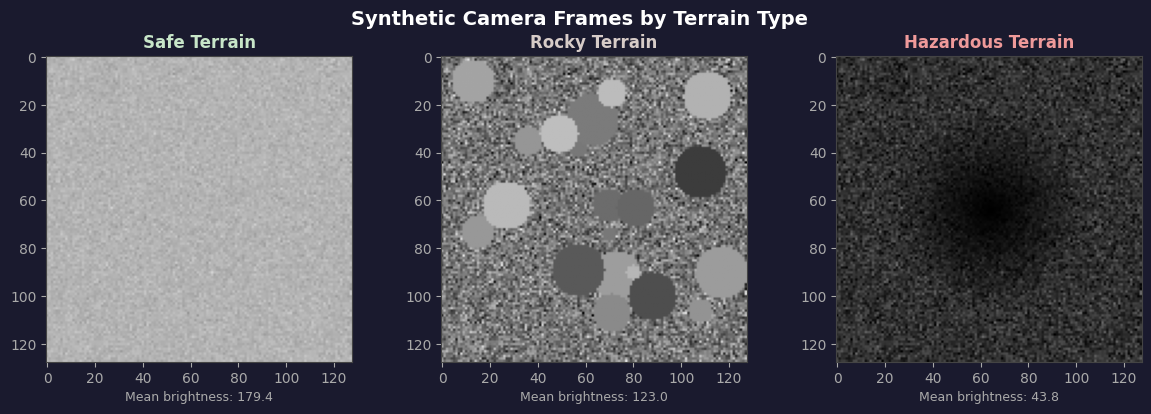

In [3]:
# Synthetic terrain image generator
def generate_terrain_frame(terrain_type, frame_size=128, seed=None):
    """
    Generate a synthetic grayscale camera frame for a given terrain type.

    Args:
        terrain_type: SAFE, ROCKY, or HAZARDOUS
        frame_size:   size of the square image in pixels
        seed:         random seed for reproducibility

    Returns:
        frame: (frame_size, frame_size) uint8 numpy array
    """
    rng = np.random.default_rng(seed)

    if terrain_type == SAFE:
        # Smooth, bright, low-variance — flat ground
        base  = rng.normal(loc=180, scale=8, size=(frame_size, frame_size))

    elif terrain_type == ROCKY:
        # High contrast, medium brightness — rocks and gravel
        base  = rng.normal(loc=120, scale=35, size=(frame_size, frame_size))
        # Add rock-like blobs
        for _ in range(20):
            cx, cy = rng.integers(10, frame_size - 10, size=2)
            r      = rng.integers(3, 12)
            val    = rng.integers(60, 200)
            for x in range(frame_size):
                for y in range(frame_size):
                    if (x - cx)**2 + (y - cy)**2 <= r**2:
                        base[x, y] = val

    elif terrain_type == HAZARDOUS:
        # Dark, irregular — craters and deep shadows
        base  = rng.normal(loc=50, scale=20, size=(frame_size, frame_size))
        # Add dark crater-like depression
        cx, cy = frame_size // 2, frame_size // 2
        for x in range(frame_size):
            for y in range(frame_size):
                dist = np.sqrt((x - cx)**2 + (y - cy)**2)
                if dist < frame_size // 3:
                    base[x, y] *= (dist / (frame_size // 3))

    # Clip to valid uint8 range
    frame = np.clip(base, 0, 255).astype(np.uint8)
    return frame


# Preview all three terrain types
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.patch.set_facecolor('#1A1A2E')

terrain_info = [
    (SAFE,      'Safe Terrain',      '#C8E6C9'),
    (ROCKY,     'Rocky Terrain',     '#D7CCC8'),
    (HAZARDOUS, 'Hazardous Terrain', '#EF9A9A'),
]

for ax, (t_type, t_label, t_colour) in zip(axes, terrain_info):
    frame = generate_terrain_frame(t_type, seed=42)
    ax.imshow(frame, cmap='gray', vmin=0, vmax=255)
    ax.set_title(t_label, color=t_colour, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Mean brightness: {frame.mean():.1f}', color='#AAAAAA', fontsize=9)
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

fig.suptitle('Synthetic Camera Frames by Terrain Type', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Degradation Functions

Three degradation types, each with a configurable `severity` parameter (0.0 to 1.0).

In [4]:
# Degradation Type 1: Gaussian Noise
def apply_gaussian_noise(frame, severity=0.3, seed=None):
    """
    Add Gaussian noise to simulate general sensor wear and interference.

    Args:
        frame:    input grayscale image (uint8)
        severity: noise intensity 0.0 (none) to 1.0 (severe)
        seed:     random seed

    Returns:
        degraded: noisy image (uint8)
    """
    rng       = np.random.default_rng(seed)
    std_dev   = severity * 80  # max std_dev of 80 at full severity
    noise     = rng.normal(0, std_dev, frame.shape)
    degraded  = np.clip(frame.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return degraded


#  Degradation Type 2: Partial Occlusion
def apply_occlusion(frame, severity=0.3, seed=None):
    """
    Block a region of the frame to simulate dust covering the lens.

    Args:
        frame:    input grayscale image (uint8)
        severity: occlusion fraction 0.0 (none) to 1.0 (fully covered)
        seed:     random seed

    Returns:
        degraded: occluded image (uint8)
    """
    rng       = np.random.default_rng(seed)
    degraded  = frame.copy()
    h, w      = frame.shape

    # Size of occluded region
    occ_h = int(h * severity * 0.9)
    occ_w = int(w * severity * 0.9)

    if occ_h > 0 and occ_w > 0:
        # Random position for occlusion block
        top  = rng.integers(0, max(1, h - occ_h))
        left = rng.integers(0, max(1, w - occ_w))
        # Fill with dust-like grey value
        dust_colour = int(rng.normal(160, 15))
        degraded[top:top + occ_h, left:left + occ_w] = dust_colour

    return degraded


#  Degradation Type 3: Intermittent Dropout
def apply_dropout(frame, severity=0.3, seed=None):
    """
    Randomly black out pixels to simulate signal instability / frame loss.

    Args:
        frame:    input grayscale image (uint8)
        severity: dropout fraction 0.0 (none) to 1.0 (all pixels lost)
        seed:     random seed

    Returns:
        degraded: image with dropped pixels (uint8)
    """
    rng      = np.random.default_rng(seed)
    degraded = frame.copy()
    mask     = rng.random(frame.shape) < severity
    degraded[mask] = 0  # Drop to black
    return degraded


print('Degradation functions defined:')
print('  apply_gaussian_noise(frame, severity)')
print('  apply_occlusion(frame, severity)')
print('  apply_dropout(frame, severity)')

Degradation functions defined:
  apply_gaussian_noise(frame, severity)
  apply_occlusion(frame, severity)
  apply_dropout(frame, severity)


---
##  Visualise Degradation Types

Side-by-side comparison of all three degradation types across mild / moderate / severe.

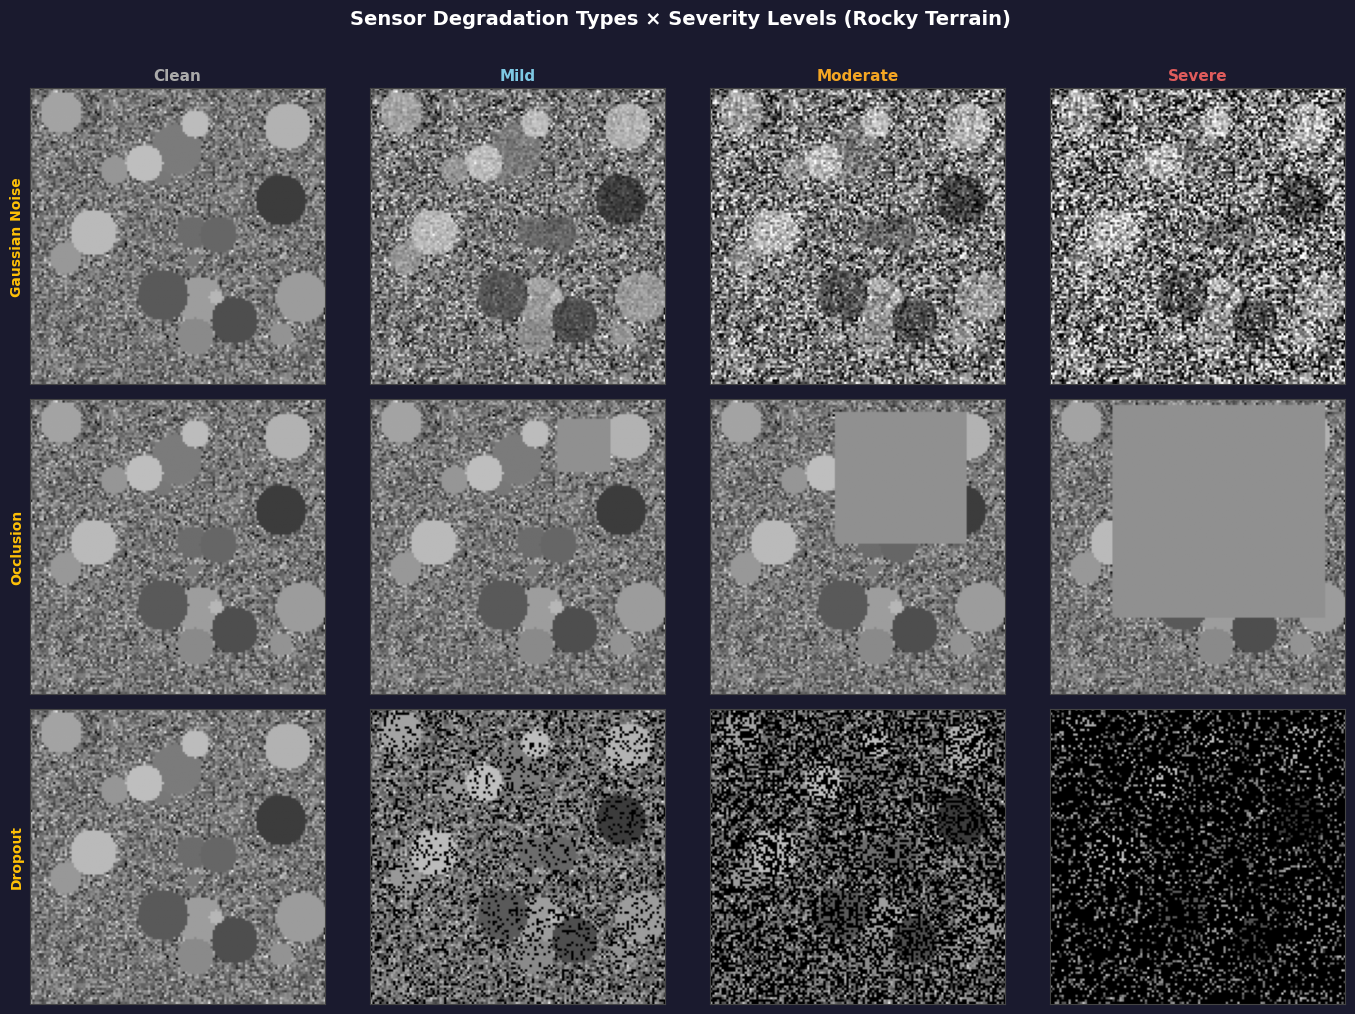

In [5]:
#  Severity levels
SEVERITY_LEVELS = {
    'Clean':    0.0,
    'Mild':     0.2,
    'Moderate': 0.5,
    'Severe':   0.8,
}

DEGRADATION_FNS = {
    'Gaussian Noise':  apply_gaussian_noise,
    'Occlusion':       apply_occlusion,
    'Dropout':         apply_dropout,
}

# Use rocky terrain as the demo frame (most interesting visually)
clean_frame = generate_terrain_frame(ROCKY, seed=42)

fig, axes = plt.subplots(
    len(DEGRADATION_FNS), len(SEVERITY_LEVELS),
    figsize=(14, 10)
)
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle(
    'Sensor Degradation Types × Severity Levels (Rocky Terrain)',
    color='white', fontsize=14, fontweight='bold', y=1.01
)

col_colours = ['#AAAAAA', '#7EC8E3', '#F4A623', '#E05C5C']

for row_idx, (deg_name, deg_fn) in enumerate(DEGRADATION_FNS.items()):
    for col_idx, (sev_name, sev_val) in enumerate(SEVERITY_LEVELS.items()):
        ax = axes[row_idx][col_idx]

        if sev_val == 0.0:
            frame = clean_frame
        else:
            frame = deg_fn(clean_frame, severity=sev_val, seed=42)

        ax.imshow(frame, cmap='gray', vmin=0, vmax=255)
        ax.set_facecolor('#1A1A2E')

        if row_idx == 0:
            ax.set_title(sev_name, color=col_colours[col_idx],
                         fontsize=11, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(deg_name, color='#FFC107',
                          fontsize=10, fontweight='bold')

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#444444')

plt.tight_layout()
plt.show()

---
##  Image Quality Metrics

To detect degradation programmatically, we need measurable quality metrics.

| Metric | What it measures | Good value |
|--------|-----------------|------------|
| **SSIM** | Structural similarity to clean frame (0–1) | Close to 1.0 |
| **PSNR** | Peak signal-to-noise ratio in dB | Above 30 dB |
| **Mean brightness** | Average pixel value | Stable vs clean |
| **Std deviation** | Pixel variance | Stable vs clean |



In [6]:
#  Quality metric calculation
def compute_quality_metrics(clean, degraded):
    """
    Compute image quality metrics comparing a degraded frame to the clean original.

    Args:
        clean:    original clean frame (uint8)
        degraded: degraded frame (uint8)

    Returns:
        dict of metric name -> value
    """
    ssim_score = ssim(clean, degraded, data_range=255)
    psnr_score = psnr(clean, degraded, data_range=255)
    mean_val   = degraded.mean()
    std_val    = degraded.std()

    return {
        'ssim':       round(ssim_score, 4),
        'psnr':       round(psnr_score, 2),
        'mean':       round(mean_val,   2),
        'std':        round(std_val,    2),
    }


# Compute metrics across all combinations
print(f'{"-" * 72}')
print(f'{"Degradation":<20} {"Severity":<12} {"SSIM":>8} {"PSNR (dB)":>10} {"Mean":>8} {"Std":>8}')
print(f'{"-" * 72}')

all_metrics = {}

for deg_name, deg_fn in DEGRADATION_FNS.items():
    all_metrics[deg_name] = {}
    for sev_name, sev_val in SEVERITY_LEVELS.items():
        if sev_val == 0.0:
            frame = clean_frame
        else:
            frame = deg_fn(clean_frame, severity=sev_val, seed=42)

        m = compute_quality_metrics(clean_frame, frame)
        all_metrics[deg_name][sev_name] = m

        print(f'{deg_name:<20} {sev_name:<12} {m["ssim"]:>8.4f} {m["psnr"]:>10.2f} {m["mean"]:>8.2f} {m["std"]:>8.2f}')

    print(f'{"-" * 72}')

------------------------------------------------------------------------
Degradation          Severity         SSIM  PSNR (dB)     Mean      Std
------------------------------------------------------------------------
Gaussian Noise       Clean          1.0000        inf   123.04    37.49
Gaussian Noise       Mild           0.8431      24.21   122.49    49.56
Gaussian Noise       Moderate       0.6709      16.98   122.76    66.64
Gaussian Noise       Severe         0.5690      13.92   123.15    79.26
------------------------------------------------------------------------
Occlusion            Clean          1.0000        inf   123.04    37.49
Occlusion            Mild           0.9677      30.57   123.75    37.12
Occlusion            Moderate       0.8052      22.09   127.71    34.32
Occlusion            Severe         0.5198      18.11   134.00    27.20
------------------------------------------------------------------------
Dropout              Clean          1.0000        inf   123.


## Degradation Curves

How SSIM and PSNR drop as severity increases for each degradation type.


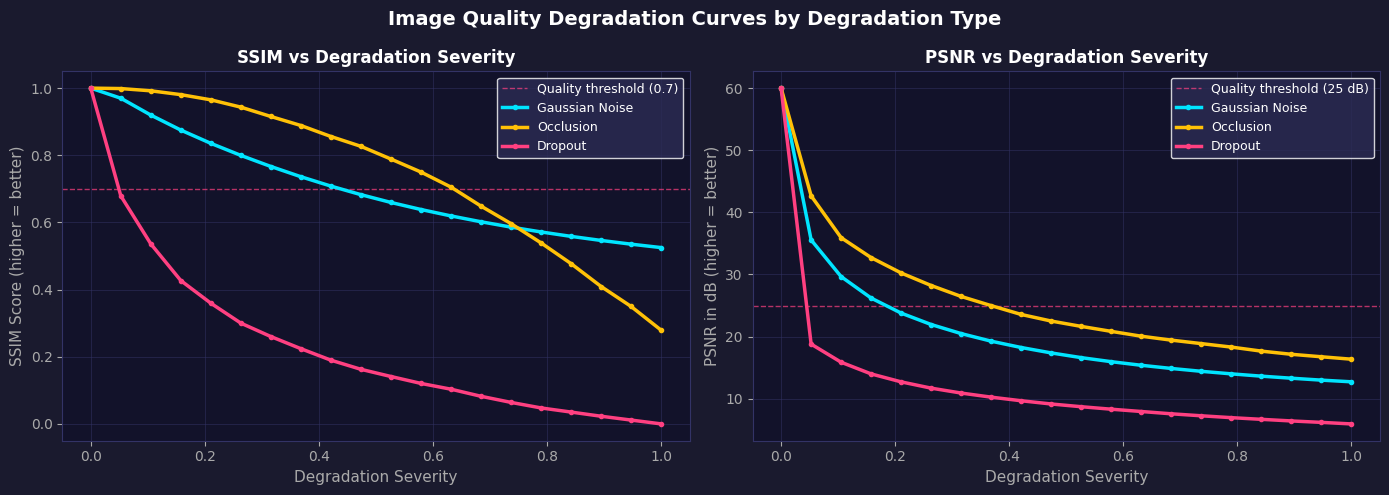


Key observation:
The red dashed lines show the quality thresholds below which
the Sensor Quality Monitor will trigger a replanning event.


In [7]:
#  Compute fine-grained degradation curves
SEVERITY_RANGE = np.linspace(0, 1, 20)
CURVE_COLOURS  = ['#00E5FF', '#FFC107', '#FF4081']

curve_data = {}
for deg_name, deg_fn in DEGRADATION_FNS.items():
    ssim_vals, psnr_vals = [], []
    for sev in SEVERITY_RANGE:
        if sev == 0:
            frame = clean_frame
        else:
            frame = deg_fn(clean_frame, severity=sev, seed=42)
        m = compute_quality_metrics(clean_frame, frame)
        ssim_vals.append(m['ssim'])
        psnr_vals.append(min(m['psnr'], 60))  # Cap PSNR for clean frame display
    curve_data[deg_name] = {'ssim': ssim_vals, 'psnr': psnr_vals}


#  Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1A1A2E')

for ax in [ax1, ax2]:
    ax.set_facecolor('#12122A')
    ax.tick_params(colors='#AAAAAA')
    ax.set_xlabel('Degradation Severity', color='#AAAAAA', fontsize=11)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333366')
    ax.grid(True, color='#333366', linewidth=0.5, alpha=0.7)

# SSIM plot
ax1.set_title('SSIM vs Degradation Severity', color='white', fontsize=12, fontweight='bold')
ax1.set_ylabel('SSIM Score (higher = better)', color='#AAAAAA', fontsize=11)
ax1.axhline(y=0.7, color='#FF4081', linestyle='--', linewidth=1, alpha=0.7, label='Quality threshold (0.7)')
for (deg_name, data), colour in zip(curve_data.items(), CURVE_COLOURS):
    ax1.plot(SEVERITY_RANGE, data['ssim'], color=colour, linewidth=2.5, label=deg_name, marker='o', markersize=3)
ax1.legend(facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=9)
ax1.set_ylim(-0.05, 1.05)

# PSNR plot
ax2.set_title('PSNR vs Degradation Severity', color='white', fontsize=12, fontweight='bold')
ax2.set_ylabel('PSNR in dB (higher = better)', color='#AAAAAA', fontsize=11)
ax2.axhline(y=25, color='#FF4081', linestyle='--', linewidth=1, alpha=0.7, label='Quality threshold (25 dB)')
for (deg_name, data), colour in zip(curve_data.items(), CURVE_COLOURS):
    ax2.plot(SEVERITY_RANGE, data['psnr'], color=colour, linewidth=2.5, label=deg_name, marker='o', markersize=3)
ax2.legend(facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=9)

fig.suptitle('Image Quality Degradation Curves by Degradation Type', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey observation:')
print('The red dashed lines show the quality thresholds below which')
print('the Sensor Quality Monitor will trigger a replanning event.')


##  Simulating a Live Degrading Camera Feed

Simulating what happens as a rover mission progresses and sensors degrade over time.
Degradation increases gradually — exactly as it would on a real Mars mission.

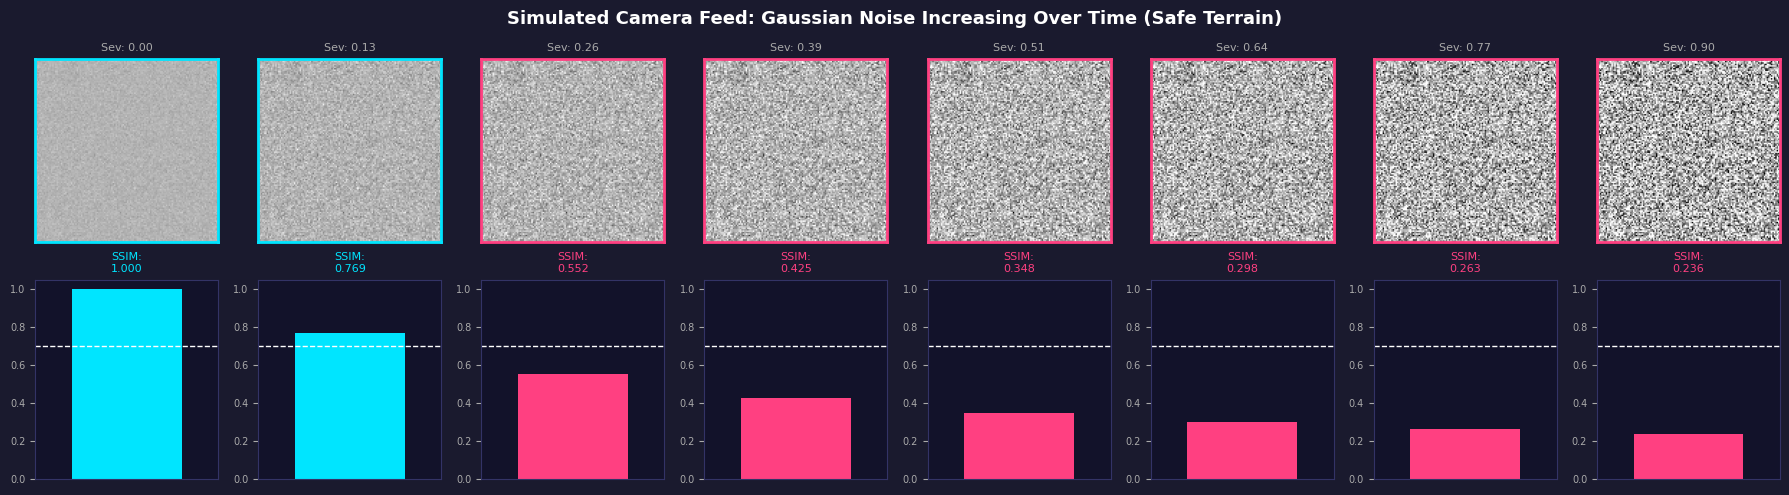


Red border/bar = SSIM below threshold (0.7) → replanning triggered
Blue border/bar = SSIM above threshold → continue current path


In [8]:
#  Simulate a sequence of frames with increasing degradation
def simulate_degrading_feed(terrain_type, degradation_fn, num_frames=8, seed=42):
    """
    Simulate a camera feed where degradation increases over time.

    Args:
        terrain_type:   SAFE, ROCKY, or HAZARDOUS
        degradation_fn: one of the three degradation functions
        num_frames:     number of frames to generate
        seed:           random seed

    Returns:
        frames:     list of degraded frames
        severities: list of severity values used
        metrics:    list of quality metric dicts
    """
    clean      = generate_terrain_frame(terrain_type, seed=seed)
    severities = np.linspace(0, 0.9, num_frames)
    frames, metrics = [], []

    for sev in severities:
        if sev == 0:
            frame = clean.copy()
        else:
            frame = degradation_fn(clean, severity=sev, seed=seed)
        frames.append(frame)
        metrics.append(compute_quality_metrics(clean, frame))

    return frames, severities, metrics, clean


# Plot degrading feed for Gaussian noise on safe terrain
frames, severities, metrics, clean = simulate_degrading_feed(
    SAFE, apply_gaussian_noise, num_frames=8
)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('Simulated Camera Feed: Gaussian Noise Increasing Over Time (Safe Terrain)',
             color='white', fontsize=13, fontweight='bold')

SSIM_THRESHOLD = 0.7

for i, (frame, sev, m) in enumerate(zip(frames, severities, metrics)):
    # Top row: frames
    ax_img = axes[0][i]
    ax_img.imshow(frame, cmap='gray', vmin=0, vmax=255)
    ax_img.set_xticks([])
    ax_img.set_yticks([])

    # Highlight frames below quality threshold
    border_col = '#FF4081' if m['ssim'] < SSIM_THRESHOLD else '#00E5FF'
    for spine in ax_img.spines.values():
        spine.set_edgecolor(border_col)
        spine.set_linewidth(2)

    ax_img.set_title(f'Sev: {sev:.2f}', color='#AAAAAA', fontsize=8)

    # Bottom row: SSIM score bar
    ax_bar = axes[1][i]
    bar_col = '#FF4081' if m['ssim'] < SSIM_THRESHOLD else '#00E5FF'
    ax_bar.bar(0, m['ssim'], color=bar_col, width=0.6)
    ax_bar.axhline(SSIM_THRESHOLD, color='white', linestyle='--', linewidth=1)
    ax_bar.set_ylim(0, 1.05)
    ax_bar.set_xlim(-0.5, 0.5)
    ax_bar.set_xticks([])
    ax_bar.set_facecolor('#12122A')
    ax_bar.set_title(f'SSIM:\n{m["ssim"]:.3f}', color=bar_col, fontsize=8)
    ax_bar.tick_params(colors='#AAAAAA', labelsize=7)
    for spine in ax_bar.spines.values():
        spine.set_edgecolor('#333366')

plt.tight_layout()
plt.show()

print('\nRed border/bar = SSIM below threshold (0.7) → replanning triggered')
print('Blue border/bar = SSIM above threshold → continue current path')

---
## Degradation Summary Table


In [9]:
# Summary table
print('SENSOR DEGRADATION SUMMARY')
print('=' * 72)
print(f'{"Degradation Type":<22} {"Severity":<12} {"SSIM":>8} {"PSNR":>10} {"Status":>12}')
print('=' * 72)

for deg_name, deg_fn in DEGRADATION_FNS.items():
    for sev_name, sev_val in SEVERITY_LEVELS.items():
        if sev_val == 0.0:
            frame = clean_frame
        else:
            frame = deg_fn(clean_frame, severity=sev_val, seed=42)
        m      = compute_quality_metrics(clean_frame, frame)
        status = 'REPLAN' if m['ssim'] < 0.7 else 'OK'
        print(f'{deg_name:<22} {sev_name:<12} {m["ssim"]:>8.4f} {m["psnr"]:>10.2f} {status:>12}')
    print('-' * 72)

print('\nSSIM threshold for replanning trigger: 0.7')
print('REPLAN = sensor quality below threshold → adaptive replanning activated')

SENSOR DEGRADATION SUMMARY
Degradation Type       Severity         SSIM       PSNR       Status
Gaussian Noise         Clean          1.0000        inf           OK
Gaussian Noise         Mild           0.8431      24.21           OK
Gaussian Noise         Moderate       0.6709      16.98       REPLAN
Gaussian Noise         Severe         0.5690      13.92       REPLAN
------------------------------------------------------------------------
Occlusion              Clean          1.0000        inf           OK
Occlusion              Mild           0.9677      30.57           OK
Occlusion              Moderate       0.8052      22.09           OK
Occlusion              Severe         0.5198      18.11       REPLAN
------------------------------------------------------------------------
Dropout                Clean          1.0000        inf           OK
Dropout                Mild           0.3713      12.93       REPLAN
Dropout                Moderate       0.1531       8.94       REPLAN